# Домашнее задание 1. Обучение без учителя

## 1. Выбор и описание данных

Для работы выбран датасет **Mice Protein Expression** из UCI Machine Learning Repository: https://archive.ics.uci.edu/dataset/342/mice+protein+expression.

Датасет содержит измерения уровней экспрессии белков в коре головного мозга мышей. В эксперименте сравнивались контрольные мыши и мыши с трисомией, моделирующей синдром Дауна. Также учитывались тип поведения в эксперименте и лечение мемантином или физиологическим раствором.

- **77 числовых признаков**: уровни экспрессии белков и белковых модификаций
- **1080 измерений**
- в данных есть пропуски

Источник: Higuera, C., Gardiner, K., & Cios, K. (2015). *Mice Protein Expression* [Dataset]. UCI Machine Learning Repository. DOI: https://doi.org/10.24432/C50S3Z.

In [117]:
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.4f}".format)

In [118]:
DATA_PATH = Path("mice_protein_expression.xls")
if not DATA_PATH.exists():
    DATA_PATH = Path("1HW") / DATA_PATH


df = pd.read_excel(DATA_PATH)
df.head()

,MouseID,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,pELK_N,pERK_N,pJNK_N,PKCA_N,pMEK_N,...,pGSK3B_Tyr216_N,SHH_N,BAD_N,BCL2_N,pS6_N,pCFOS_N,SYP_N,H3AcK18_N,EGR1_N,H3MeK4_N,CaNA_N,Genotype,Treatment,Behavior,class
0,309_1,0.5036,0.7472,0.4302,2.8163,5.9902,0.2188,0.1776,2.3737,0.2322,1.7509,0.6879,0.3064,0.4027,0.2969,...,0.8316,0.1889,0.1227,NaN,0.1063,0.1083,0.4271,0.1148,0.1318,0.1282,1.6757,Control,Memantine,C/S,c-CS-m
1,309_2,0.5146,0.6891,0.4118,2.7895,5.6850,0.2116,0.1728,2.2921,0.2270,1.5964,0.6950,0.2991,0.3860,0.2813,...,0.8493,0.2004,0.1167,NaN,0.1066,0.1043,0.4416,0.1120,0.1351,0.1311,1.7436,Control,Memantine,C/S,c-CS-m
2,309_3,0.5092,0.7302,0.4183,2.6872,5.6221,0.2090,0.1757,2.2833,0.2302,1.5613,0.6773,0.2913,0.3810,0.2817,...,0.8467,0.1937,0.1185,NaN,0.1083,0.1062,0.4358,0.1119,0.1334,0.1274,1.9264,Control,Memantine,C/S,c-CS-m
3,309_4,0.4421,0.6171,0.3586,2.4669,4.9795,0.2229,0.1765,2.1523,0.2070,1.5951,0.5833,0.2967,0.3771,0.3138,...,0.8333,0.1921,0.1328,NaN,0.1032,0.1113,0.3917,0.1304,0.1474,0.1469,1.7006,Control,Memantine,C/S,c-CS-m
4,309_5,0.4349,0.6174,0.3588,2.3658,4.7187,0.2131,0.1736,2.1340,0.1922,1.5042,0.5510,0.2870,0.3635,0.2780,...,0.8787,0.2056,0.1300,NaN,0.1048,0.1107,0.4342,0.1185,0.1403,0.1484,1.8397,Control,Memantine,C/S,c-CS-m


In [119]:
df.shape

(1080, 82)

В локальном файле 1080 строк и 82 столбца. Из них:

- `MouseID` — идентификатор измерения;
- 77 столбцов с окончанием `_N` — числовые признаки экспрессии белков;
- `Genotype`, `Treatment`, `Behavior` — категориальные описания условий эксперимента;
- `class` — объединенная метка одной из восьми групп мышей.

Для кластеризации будем использовать только 77 числовых белковых признаков. Категориальные столбцы и `class` не будут подаваться в алгоритмы как признаки, но пригодятся позже для интерпретации кластеров и расчета внешних метрик.

In [120]:
id_column = "MouseID"
meta_columns = ["Genotype", "Treatment", "Behavior", "class"]
protein_features = [column for column in df.columns if column not in [id_column, *meta_columns]]

summary = pd.DataFrame(
    {
        "group": ["objects", "total_columns", "protein_features", "meta_columns"],
        "count": [len(df), df.shape[1], len(protein_features), len(meta_columns)],
    }
)
summary

,group,count
0,objects,1080
1,total_columns,82
2,protein_features,77
3,meta_columns,4


In [121]:
df[protein_features].describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
DYRK1A_N,1077.0000,0.4258,0.2494,0.1453,0.2881,0.3664,0.4877,2.5164
ITSN1_N,1077.0000,0.6171,0.2516,0.2454,0.4734,0.5658,0.6980,2.6027
BDNF_N,1077.0000,0.3191,0.0494,0.1152,0.2874,0.3166,0.3482,0.4972
NR1_N,1077.0000,2.2973,0.3473,1.3308,2.0574,2.2965,2.5285,3.7576
NR2A_N,1077.0000,3.8439,0.9331,1.7375,3.1557,3.7609,4.4400,8.4826
pAKT_N,1077.0000,0.2332,0.0416,0.0632,0.2058,0.2312,0.2573,0.5391
pBRAF_N,1077.0000,0.1818,0.0270,0.0640,0.1646,0.1823,0.1974,0.3171
pCAMKII_N,1077.0000,3.5371,1.2952,1.3440,2.4798,3.3265,4.4819,7.4641
pCREB_N,1077.0000,0.2126,0.0326,0.1128,0.1908,0.2106,0.2346,0.3062
pELK_N,1077.0000,1.4287,0.4669,0.4290,1.2037,1.3558,1.5613,6.1133


In [122]:
class_distribution = df["class"].value_counts().sort_index()
class_distribution

class
c-CS-m    150
c-CS-s    135
c-SC-m    150
c-SC-s    135
t-CS-m    135
t-CS-s    105
t-SC-m    135
t-SC-s    135
Name: count, dtype: int64

In [123]:
df[["Genotype", "Treatment", "Behavior", "class"]].nunique()

Genotype     2
Treatment    2
Behavior     2
class        8
dtype: int64

In [124]:
missing_summary = (
    df[protein_features]
    .isna()
    .sum()
    .sort_values(ascending=False)
    .rename("missing_count")
    .to_frame()
)
missing_summary["missing_share"] = missing_summary["missing_count"] / len(df)
missing_summary.query("missing_count > 0").head(15)

,missing_count,missing_share
BCL2_N,285,0.2639
H3MeK4_N,270,0.2500
BAD_N,213,0.1972
EGR1_N,210,0.1944
H3AcK18_N,180,0.1667
pCFOS_N,75,0.0694
ELK_N,18,0.0167
Bcatenin_N,18,0.0167
MEK_N,7,0.0065
ITSN1_N,3,0.0028


## 2. Разведочный анализ и подготовка данных

In [125]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")

### 2.1. Базовые проверки

Сначала проверим типы столбцов, наличие дубликатов и соответствие набора числовых признаков ожидаемой структуре.

In [126]:
basic_checks = pd.DataFrame(
    {
        "check": [
            "rows",
            "columns",
            "protein_features",
            "duplicated_rows",
            "duplicated_mouse_id",
            "numeric_protein_features",
        ],
        "value": [
            len(df),
            df.shape[1],
            len(protein_features),
            df.duplicated().sum(),
            df[id_column].duplicated().sum(),
            df[protein_features].select_dtypes(include="number").shape[1],
        ],
    }
)
basic_checks

,check,value
0,rows,1080
1,columns,82
2,protein_features,77
3,duplicated_rows,0
4,duplicated_mouse_id,0
5,numeric_protein_features,77


In [127]:
df[[id_column, *meta_columns]].head()

,MouseID,Genotype,Treatment,Behavior,class
0,309_1,Control,Memantine,C/S,c-CS-m
1,309_2,Control,Memantine,C/S,c-CS-m
2,309_3,Control,Memantine,C/S,c-CS-m
3,309_4,Control,Memantine,C/S,c-CS-m
4,309_5,Control,Memantine,C/S,c-CS-m


### 2.2. Баланс экспериментальных групп

Посмотрим, насколько равномерно представлены известные группы. Эти столбцы не будут использоваться как признаки, но полезны для понимания данных и дальнейшей интерпретации кластеров.

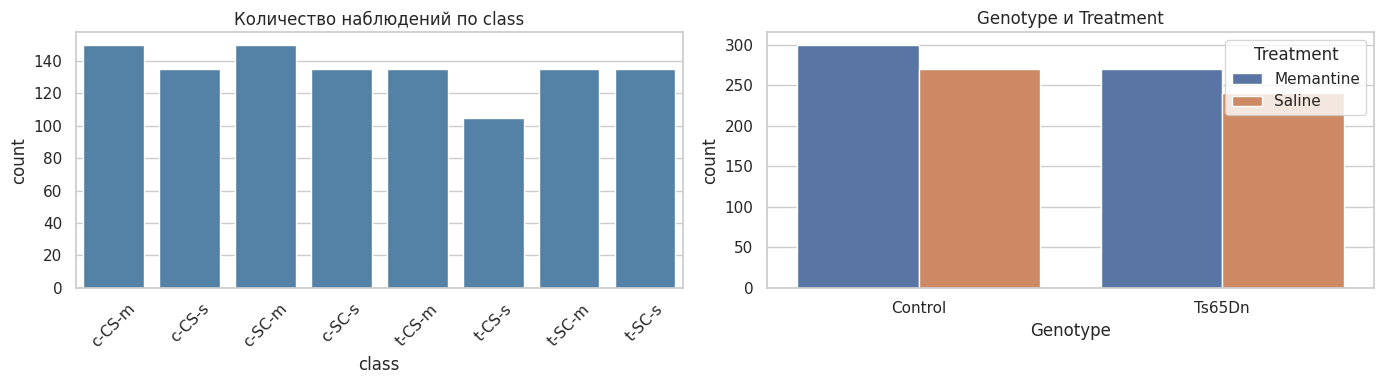

In [128]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.countplot(data=df, x="class", order=sorted(df["class"].unique()), ax=axes[0], color="steelblue")
axes[0].set_title("Количество наблюдений по class")
axes[0].set_xlabel("class")
axes[0].set_ylabel("count")
axes[0].tick_params(axis="x", rotation=45)

sns.countplot(data=df, x="Genotype", hue="Treatment", ax=axes[1])
axes[1].set_title("Genotype и Treatment")
axes[1].set_xlabel("Genotype")
axes[1].set_ylabel("count")

plt.tight_layout()

In [129]:
group_counts = (
    df.groupby(["Genotype", "Treatment", "Behavior", "class"], observed=True)
    .size()
    .rename("count")
    .reset_index()
    .sort_values("class")
)
group_counts

,Genotype,Treatment,Behavior,class,count
0,Control,Memantine,C/S,c-CS-m,150
2,Control,Saline,C/S,c-CS-s,135
1,Control,Memantine,S/C,c-SC-m,150
3,Control,Saline,S/C,c-SC-s,135
4,Ts65Dn,Memantine,C/S,t-CS-m,135
6,Ts65Dn,Saline,C/S,t-CS-s,105
5,Ts65Dn,Memantine,S/C,t-SC-m,135
7,Ts65Dn,Saline,S/C,t-SC-s,135


### 2.3. Пропуски

In [130]:
missing_features = missing_summary.query("missing_count > 0").copy()
missing_features["missing_percent"] = 100 * missing_features["missing_share"]
missing_features.head(20)

,missing_count,missing_share,missing_percent
BCL2_N,285,0.2639,26.3889
H3MeK4_N,270,0.2500,25.0000
BAD_N,213,0.1972,19.7222
EGR1_N,210,0.1944,19.4444
H3AcK18_N,180,0.1667,16.6667
pCFOS_N,75,0.0694,6.9444
ELK_N,18,0.0167,1.6667
Bcatenin_N,18,0.0167,1.6667
MEK_N,7,0.0065,0.6481
ITSN1_N,3,0.0028,0.2778


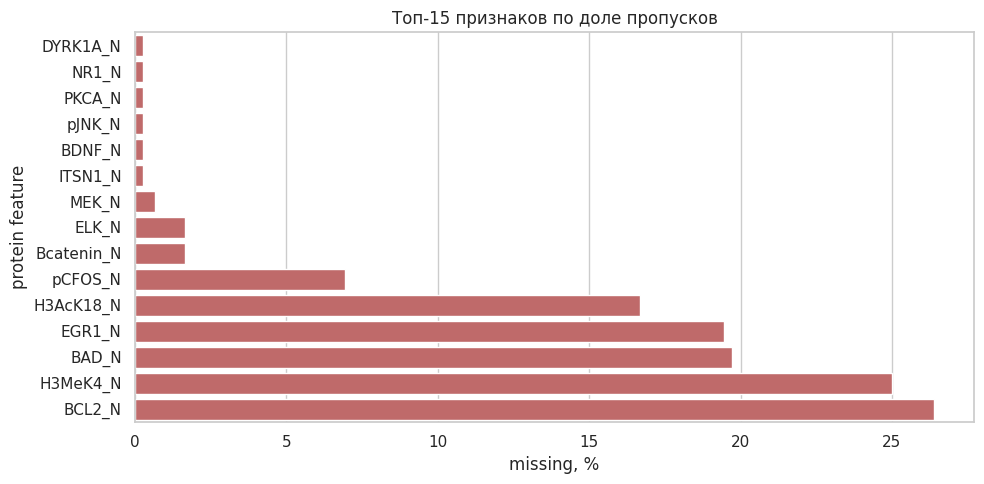

In [131]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_data = missing_features.head(15).sort_values("missing_percent")
sns.barplot(data=plot_data, x="missing_percent", y=plot_data.index, ax=ax, color="indianred")
ax.set_title("Топ-15 признаков по доле пропусков")
ax.set_xlabel("missing, %")
ax.set_ylabel("protein feature")
plt.tight_layout()

In [132]:
missing_overview = pd.DataFrame(
    {
        "features_with_missing": [(missing_summary["missing_count"] > 0).sum()],
        "max_missing_count": [missing_summary["missing_count"].max()],
        "max_missing_share": [missing_summary["missing_share"].max()],
        "total_missing_values": [df[protein_features].isna().sum().sum()],
    }
)
missing_overview

,features_with_missing,max_missing_count,max_missing_share,total_missing_values
0,49,285,0.2639,1396


Основная масса пропусков сосредоточена в нескольких белках, хотя единичные пропуски встречаются во многих столбцах. Для дальнейшей кластеризации используем медианную импутацию.


### 2.4. Распределения и масштаб признаков

Белковые признаки имеют разные диапазоны и дисперсии. Для методов на расстояниях, особенно K-means и DBSCAN, это критично: признаки с большим масштабом могут искусственно доминировать в расстояниях.

In [133]:
feature_ranges = df[protein_features].agg(["min", "median", "max", "mean", "std"]).T
feature_ranges["range"] = feature_ranges["max"] - feature_ranges["min"]
feature_ranges.sort_values("range", ascending=False).head(10)

,min,median,max,mean,std,range
NR2A_N,1.7375,3.7609,8.4826,3.8439,0.9331,6.7450
pCAMKII_N,1.3440,3.3265,7.4641,3.5371,1.2952,6.1201
pELK_N,0.4290,1.3558,6.1133,1.4287,0.4669,5.6843
ERK_N,1.1318,2.4015,5.1984,2.4745,0.6534,4.0666
pERK_N,0.1492,0.4436,3.5667,0.5459,0.3453,3.4175
pPKCG_N,0.5988,1.6646,3.3820,1.7066,0.5784,2.7832
Bcatenin_N,1.1349,2.1148,3.6806,2.1465,0.4357,2.5457
pPKCAB_N,0.5678,1.3657,3.0614,1.5253,0.4818,2.4935
NR1_N,1.3308,2.2965,3.7576,2.2973,0.3473,2.4268
pNR2B_N,0.3016,1.5637,2.7240,1.5620,0.2707,2.4224


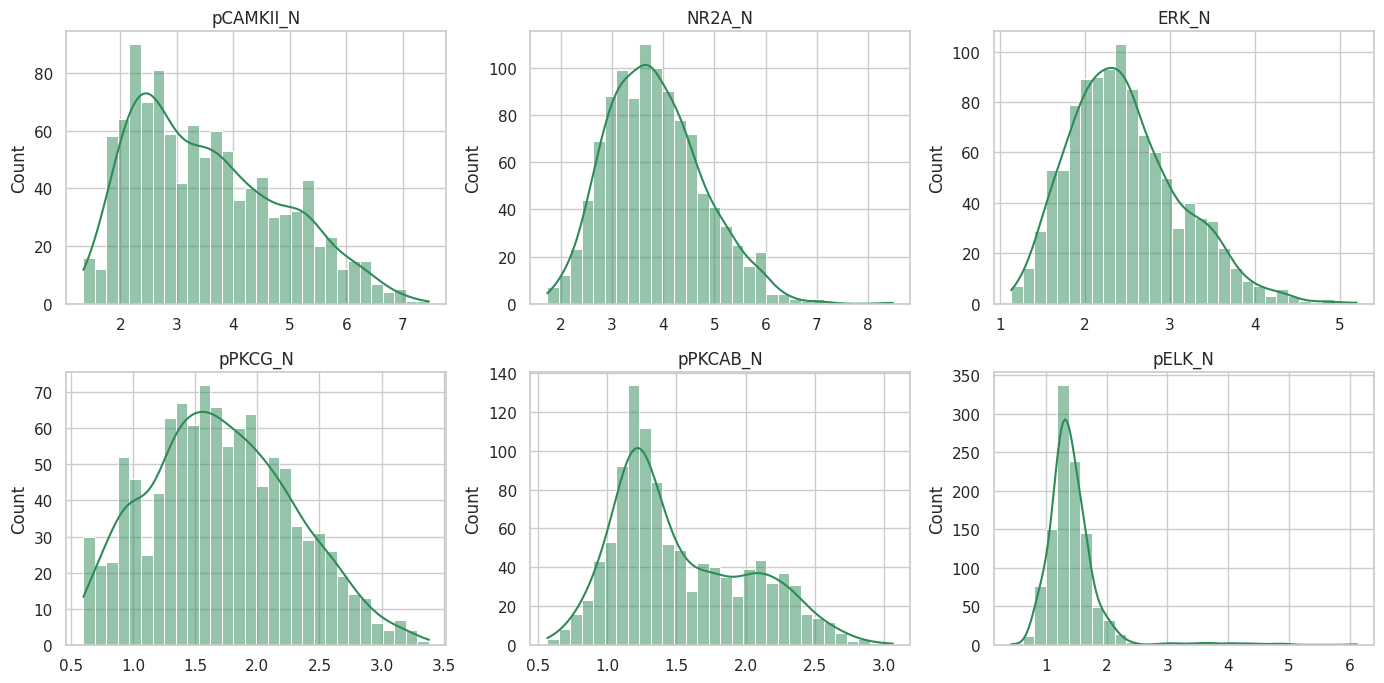

In [134]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
selected_features = feature_ranges.sort_values("std", ascending=False).head(6).index

for ax, feature in zip(axes.ravel(), selected_features):
    sns.histplot(df[feature], bins=30, kde=True, ax=ax, color="seagreen")
    ax.set_title(feature)
    ax.set_xlabel("")

plt.tight_layout()

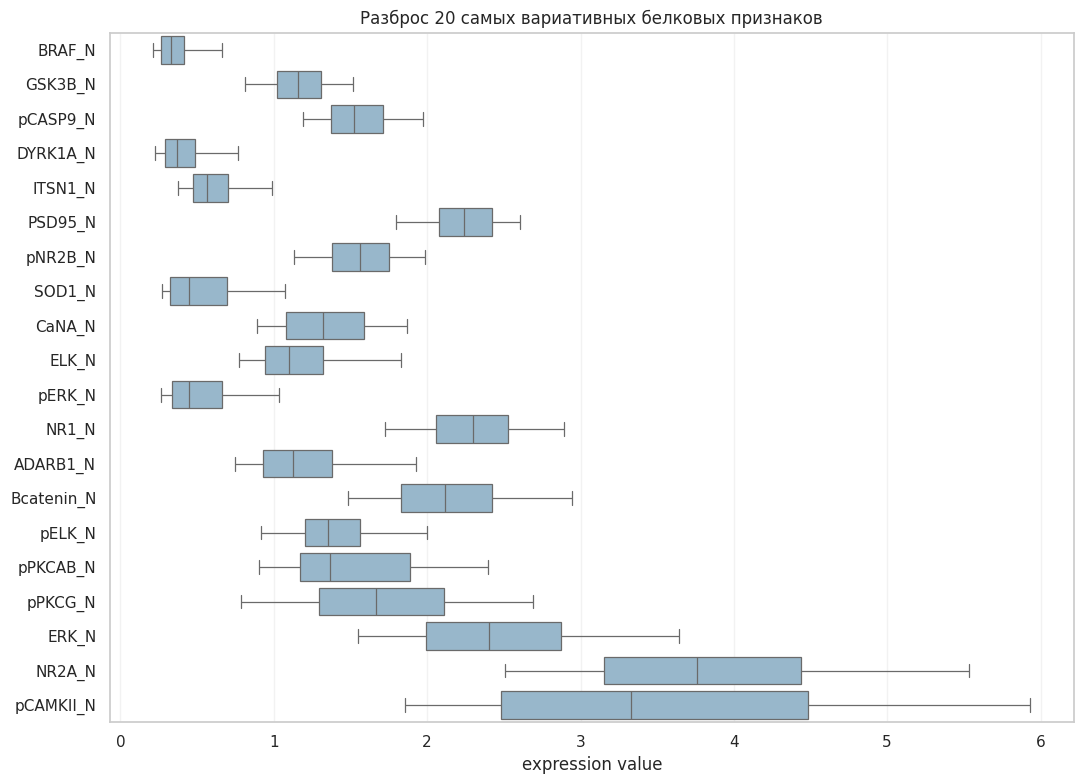

In [135]:
top_spread_features = feature_ranges.sort_values("std", ascending=False).head(20).index
spread_plot_data = (
    df[top_spread_features]
    .melt(var_name="protein", value_name="expression")
    .dropna()
)

fig, ax = plt.subplots(figsize=(11, 8))
sns.boxplot(
    data=spread_plot_data,
    x="expression",
    y="protein",
    order=list(reversed(top_spread_features)),
    ax=ax,
    color="#8fb9d4",
    linewidth=0.9,
    showfliers=False,
    whis=(5, 95),
)
ax.set_title("Разброс 20 самых вариативных белковых признаков")
ax.set_xlabel("expression value")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()

По исходным значениям видно, что признаки отличаются по масштабу и форме распределения. Поэтому после заполнения пропусков применяем стандартизацию: каждый белковый признак будет иметь среднее около 0 и стандартное отклонение около 1.

### 2.5. Подготовленная матрица для кластеризации

Сформируем две версии данных:

- `X_imputed` — белковые признаки после заполнения пропусков медианой;
- `X_scaled` — те же признаки после стандартизации, основная матрица для следующих моделей кластеризации.

Категориальные признаки и `class` в эти матрицы не входят.

In [136]:
X_raw = df[protein_features].copy()

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_imputed_array = imputer.fit_transform(X_raw)
X_scaled_array = scaler.fit_transform(X_imputed_array)

X_imputed = pd.DataFrame(X_imputed_array, columns=protein_features, index=df.index)
X_scaled = pd.DataFrame(X_scaled_array, columns=protein_features, index=df.index)

prepared_checks = pd.DataFrame(
    {
        "dataset": ["X_raw", "X_imputed", "X_scaled"],
        "rows": [X_raw.shape[0], X_imputed.shape[0], X_scaled.shape[0]],
        "columns": [X_raw.shape[1], X_imputed.shape[1], X_scaled.shape[1]],
        "missing_values": [
            X_raw.isna().sum().sum(),
            X_imputed.isna().sum().sum(),
            X_scaled.isna().sum().sum(),
        ],
    }
)
prepared_checks

,dataset,rows,columns,missing_values
0,X_raw,1080,77,1396
1,X_imputed,1080,77,0
2,X_scaled,1080,77,0


In [137]:
scaling_check = pd.DataFrame(
    {
        "dataset": ["before scaling", "after scaling"],
        "mean_abs_mean": [
            X_imputed.mean().abs().mean(),
            X_scaled.mean().abs().mean(),
        ],
        "mean_std": [
            X_imputed.std(ddof=0).mean(),
            X_scaled.std(ddof=0).mean(),
        ],
        "min_std": [
            X_imputed.std(ddof=0).min(),
            X_scaled.std(ddof=0).min(),
        ],
        "max_std": [
            X_imputed.std(ddof=0).max(),
            X_scaled.std(ddof=0).max(),
        ],
    }
)
scaling_check


,dataset,mean_abs_mean,mean_std,min_std,max_std
0,before scaling,0.6717,0.1576,0.0132,1.2928
1,after scaling,0.0000,1.0000,1.0000,1.0000


После преобразований получена числовая матрица `X_scaled` размера 1080 x 77 без пропусков. Она будет использоваться как основной вход для собственной реализации K-means и моделей из `sklearn`. Метки `class` сохраняются отдельно в `df["class"]` для последующего сравнения кластеров с известными экспериментальными группами.

## 3. Собственная реализация K-means


In [138]:
import sys
from pathlib import Path

for module_dir in (Path("."), Path("1HW")):
    if (module_dir / "simple_kmeans.py").exists():
        module_path = str(module_dir.resolve())
        if module_path not in sys.path:
            sys.path.append(module_path)

from simple_kmeans import SimpleKMeans


In [139]:
simple_kmeans = SimpleKMeans(n_clusters=8, max_iter=100, tol=1e-4, random_state=42)
simple_labels = simple_kmeans.fit_predict(X_scaled)

simple_kmeans_result = pd.DataFrame(
    {
        "n_clusters": [simple_kmeans.n_clusters],
        "n_iter": [simple_kmeans.n_iter_],
        "inertia": [simple_kmeans.inertia_],
        "samples": [len(simple_labels)],
        "features": [X_scaled.shape[1]],
    }
)
simple_kmeans_result


,n_clusters,n_iter,inertia,samples,features
0,8,19,49253.9092,1080,77


In [140]:
simple_cluster_counts = (
    pd.Series(simple_labels, name="cluster")
    .value_counts()
    .sort_index()
    .rename_axis("cluster")
    .to_frame("count")
)
simple_cluster_counts


,count
cluster,
0,103
1,87
2,188
3,97
4,216
5,138
6,120
7,131


In [141]:
pd.crosstab(
    pd.Series(simple_labels, name="cluster"),
    df["class"],
)


class,c-CS-m,c-CS-s,c-SC-m,c-SC-s,t-CS-m,t-CS-s,t-SC-m,t-SC-s
cluster,,,,,,,,
0,43,32,0,0,13,15,0,0
1,5,5,2,8,0,0,32,35
2,32,34,0,0,62,41,0,19
3,17,31,3,0,9,11,7,19
4,17,0,65,68,0,0,50,16
5,17,0,42,29,0,3,40,7
6,15,33,0,0,39,33,0,0
7,4,0,38,30,12,2,6,39


Собственная реализация успешно строит 8 кластеров на подготовленной матрице. Таблица распределения показывает, что кластеры не пустые, а кросс-таблица с `class` нужна только для первичной интерпретации: при обучении эти метки не используются.


## 4. Обучение базовых моделей кластеризации

Обучим три базовые модели на одной и той же подготовленной матрице `X_scaled`: собственный `SimpleKMeans`, `KMeans` из `sklearn` и `AffinityPropagation` из `sklearn`. Для K-means моделей задаем `8` кластеров, потому что в данных есть 8 известных экспериментальных классов. `AffinityPropagation` сам выбирает число кластеров, поэтому для него фиксируем только параметры сходимости и `preference`.


In [142]:
from sklearn.cluster import AffinityPropagation, KMeans
from sklearn.metrics import pairwise_distances

base_n_clusters = 8

affinity_similarity = -pairwise_distances(X_scaled, metric="sqeuclidean")
affinity_off_diagonal = affinity_similarity[np.triu_indices_from(affinity_similarity, k=1)]
base_affinity_preference = float(np.quantile(affinity_off_diagonal, 0.001))

sklearn_kmeans = KMeans(n_clusters=base_n_clusters, n_init=20, random_state=42)
sklearn_kmeans_labels = sklearn_kmeans.fit_predict(X_scaled)

affinity_propagation = AffinityPropagation(
    damping=0.85,
    preference=base_affinity_preference,
    max_iter=120,
    convergence_iter=10,
    random_state=42,
)
affinity_propagation_labels = affinity_propagation.fit_predict(X_scaled)

trained_models = {
    "SimpleKMeans": {
        "implementation": "custom",
        "model": simple_kmeans,
        "labels": simple_labels,
    },
    "sklearn KMeans": {
        "implementation": "sklearn",
        "model": sklearn_kmeans,
        "labels": sklearn_kmeans_labels,
    },
    "sklearn AffinityPropagation": {
        "implementation": "sklearn",
        "model": affinity_propagation,
        "labels": affinity_propagation_labels,
    },
}


In [143]:
model_summaries = []

for model_name, run in trained_models.items():
    labels = pd.Series(run["labels"])
    cluster_sizes = labels.value_counts().sort_index()
    model = run["model"]

    model_summaries.append(
        {
            "model": model_name,
            "implementation": run["implementation"],
            "clusters_found": labels.nunique(),
            "min_cluster_size": cluster_sizes.min(),
            "max_cluster_size": cluster_sizes.max(),
            "inertia": getattr(model, "inertia_", np.nan),
            "n_iter": getattr(model, "n_iter_", np.nan),
        }
    )

base_model_summary = pd.DataFrame(model_summaries)
base_model_summary


,model,implementation,clusters_found,min_cluster_size,max_cluster_size,inertia,n_iter
0,SimpleKMeans,custom,8,87,216,49253.9092,19
1,sklearn KMeans,sklearn,8,15,204,47689.4524,27
2,sklearn AffinityPropagation,sklearn,27,15,96,NaN,44


In [144]:
cluster_size_tables = []

for model_name, run in trained_models.items():
    cluster_size = (
        pd.Series(run["labels"], name="cluster")
        .value_counts()
        .sort_index()
        .rename("count")
        .to_frame()
    )
    cluster_size.insert(0, "model", model_name)
    cluster_size_tables.append(cluster_size.reset_index())

base_cluster_sizes = pd.concat(cluster_size_tables, ignore_index=True)
base_cluster_sizes


,cluster,model,count
0,0,SimpleKMeans,103
1,1,SimpleKMeans,87
2,2,SimpleKMeans,188
3,3,SimpleKMeans,97
4,4,SimpleKMeans,216
5,5,SimpleKMeans,138
6,6,SimpleKMeans,120
7,7,SimpleKMeans,131
8,0,sklearn KMeans,144
9,1,sklearn KMeans,172


In [145]:
base_labels = pd.DataFrame(
    {model_name: run["labels"] for model_name, run in trained_models.items()},
    index=df.index,
)
base_labels.head()


,SimpleKMeans,sklearn KMeans,sklearn AffinityPropagation
0,0,0,17
1,0,6,17
2,0,6,17
3,2,6,15
4,2,6,15


## 5. Подбор гиперпараметров

Для K-means моделей перебираем число кластеров. Для `sklearn KMeans` дополнительно меняем `n_init`. Для `AffinityPropagation` перебираем `damping` и несколько значений `preference`, взятых как квантили матрицы сходства. Лучшие варианты выбираем по `silhouette`, потому что это внутренняя метрика и она не использует известные классы.


In [146]:
from time import perf_counter
import warnings

from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    normalized_mutual_info_score,
    silhouette_score,
)

true_class_labels = df["class"].to_numpy()


def evaluate_clustering(X, labels, true_labels):
    labels = np.asarray(labels)
    n_clusters = np.unique(labels).size
    metrics = {"clusters_found": n_clusters}

    if 1 < n_clusters < len(labels):
        metrics["silhouette"] = silhouette_score(X, labels)
        metrics["calinski_harabasz"] = calinski_harabasz_score(X, labels)
        metrics["davies_bouldin"] = davies_bouldin_score(X, labels)
    else:
        metrics["silhouette"] = np.nan
        metrics["calinski_harabasz"] = np.nan
        metrics["davies_bouldin"] = np.nan

    metrics["adjusted_rand"] = adjusted_rand_score(true_labels, labels)
    metrics["normalized_mutual_info"] = normalized_mutual_info_score(true_labels, labels)
    return metrics


def fit_and_score(model_name, implementation, model, params):
    start_time = perf_counter()
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=ConvergenceWarning)
        labels = model.fit_predict(X_scaled)
    fit_time_sec = perf_counter() - start_time

    row = {
        "model": model_name,
        "implementation": implementation,
        "fit_time_sec": fit_time_sec,
        **params,
        **evaluate_clustering(X_scaled, labels, true_class_labels),
    }
    return row, model, labels


In [147]:
tuning_rows = []
tuned_artifacts = {}
kmeans_cluster_grid = [4, 6, 8, 10, 12]
preference_quantile_grid = [0.001, 0.01, 0.05]

run_number = 0

for n_clusters in kmeans_cluster_grid:
    run_number += 1
    params = {
        "n_clusters": n_clusters,
        "n_init": np.nan,
        "damping": np.nan,
        "preference_quantile": np.nan,
        "preference": np.nan,
    }
    row, model, labels = fit_and_score(
        "SimpleKMeans",
        "custom",
        SimpleKMeans(n_clusters=n_clusters, max_iter=100, tol=1e-4, random_state=42),
        params,
    )
    row["run_id"] = f"run_{run_number:02d}"
    tuning_rows.append(row)
    tuned_artifacts[row["run_id"]] = {"model": model, "labels": labels}

for n_clusters in kmeans_cluster_grid:
    for n_init in [10, 20]:
        run_number += 1
        params = {
            "n_clusters": n_clusters,
            "n_init": n_init,
            "damping": np.nan,
            "preference_quantile": np.nan,
            "preference": np.nan,
        }
        row, model, labels = fit_and_score(
            "sklearn KMeans",
            "sklearn",
            KMeans(n_clusters=n_clusters, n_init=n_init, random_state=42),
            params,
        )
        row["run_id"] = f"run_{run_number:02d}"
        tuning_rows.append(row)
        tuned_artifacts[row["run_id"]] = {"model": model, "labels": labels}

for damping in [0.70, 0.85, 0.95]:
    for preference_quantile in preference_quantile_grid:
        preference = float(np.quantile(affinity_off_diagonal, preference_quantile))
        run_number += 1
        params = {
            "n_clusters": np.nan,
            "n_init": np.nan,
            "damping": damping,
            "preference_quantile": preference_quantile,
            "preference": preference,
        }
        row, model, labels = fit_and_score(
            "sklearn AffinityPropagation",
            "sklearn",
            AffinityPropagation(
                damping=damping,
                preference=preference,
                max_iter=120,
                convergence_iter=10,
                random_state=42,
            ),
            params,
        )
        row["run_id"] = f"run_{run_number:02d}"
        tuning_rows.append(row)
        tuned_artifacts[row["run_id"]] = {"model": model, "labels": labels}

hyperparameter_results = pd.DataFrame(tuning_rows)
hyperparameter_results = hyperparameter_results[
    ["run_id"] + [column for column in hyperparameter_results.columns if column != "run_id"]
]
hyperparameter_results.sort_values(
    ["silhouette", "calinski_harabasz"],
    ascending=[False, False],
).head(10)


,run_id,model,implementation,fit_time_sec,n_clusters,n_init,damping,preference_quantile,preference,clusters_found,silhouette,calinski_harabasz,davies_bouldin,adjusted_rand,normalized_mutual_info
20,run_21,sklearn AffinityPropagation,sklearn,0.3191,NaN,NaN,0.8500,0.0500,-324.1777,50,0.1795,49.0114,1.5879,0.1491,0.5010
17,run_18,sklearn AffinityPropagation,sklearn,0.1972,NaN,NaN,0.7000,0.0500,-324.1777,52,0.1788,48.2602,1.5823,0.1517,0.5105
23,run_24,sklearn AffinityPropagation,sklearn,0.5793,NaN,NaN,0.9500,0.0500,-324.1777,53,0.1769,46.9293,1.6145,0.1402,0.5021
22,run_23,sklearn AffinityPropagation,sklearn,0.6920,NaN,NaN,0.9500,0.0100,-474.1760,36,0.1642,55.0365,1.6138,0.1696,0.4785
19,run_20,sklearn AffinityPropagation,sklearn,0.2983,NaN,NaN,0.8500,0.0100,-474.1760,36,0.1640,54.8512,1.6225,0.1709,0.4806
16,run_17,sklearn AffinityPropagation,sklearn,0.2350,NaN,NaN,0.7000,0.0100,-474.1760,36,0.1609,53.8470,1.6683,0.1826,0.4894
18,run_19,sklearn AffinityPropagation,sklearn,0.2712,NaN,NaN,0.8500,0.0010,-665.6310,27,0.1429,60.9492,1.7195,0.1799,0.4485
21,run_22,sklearn AffinityPropagation,sklearn,0.6117,NaN,NaN,0.9500,0.0010,-665.6310,28,0.1407,59.1470,1.7467,0.1844,0.4536
13,run_14,sklearn KMeans,sklearn,0.0845,12.0000,10.0000,NaN,NaN,NaN,12,0.1317,94.6747,1.8246,0.1493,0.3264
14,run_15,sklearn KMeans,sklearn,0.1155,12.0000,20.0000,NaN,NaN,NaN,12,0.1317,94.6747,1.8246,0.1493,0.3264


In [148]:
best_runs = (
    hyperparameter_results
    .sort_values(["model", "silhouette", "calinski_harabasz"], ascending=[True, False, False])
    .groupby("model", as_index=False)
    .head(1)
    .sort_values("silhouette", ascending=False)
)
best_runs


,run_id,model,implementation,fit_time_sec,n_clusters,n_init,damping,preference_quantile,preference,clusters_found,silhouette,calinski_harabasz,davies_bouldin,adjusted_rand,normalized_mutual_info
20,run_21,sklearn AffinityPropagation,sklearn,0.3191,NaN,NaN,0.8500,0.0500,-324.1777,50,0.1795,49.0114,1.5879,0.1491,0.5010
13,run_14,sklearn KMeans,sklearn,0.0845,12.0000,10.0000,NaN,NaN,NaN,12,0.1317,94.6747,1.8246,0.1493,0.3264
3,run_04,SimpleKMeans,custom,0.0149,10.0000,NaN,NaN,NaN,NaN,10,0.1258,101.7669,1.7689,0.1504,0.2984


Таблица `best_runs` содержит лучший найденный вариант для каждой реализации. Для `silhouette`, `calinski_harabasz`, `adjusted_rand` и `normalized_mutual_info` больше значит лучше. Для `davies_bouldin` и `fit_time_sec` меньше значит лучше.


## 6. Сравнение качества и скорости

Сравним лучшие найденные конфигурации по времени обучения и нескольким метрикам качества. Внутренние метрики оценивают геометрию кластеров без знания правильных групп. Внешние метрики `adjusted_rand` и `normalized_mutual_info` сравнивают кластеры с известной колонкой `class`; эти значения нужны только для анализа результата.


In [149]:
comparison_columns = [
    "model",
    "implementation",
    "fit_time_sec",
    "clusters_found",
    "silhouette",
    "calinski_harabasz",
    "davies_bouldin",
    "adjusted_rand",
    "normalized_mutual_info",
    "n_clusters",
    "n_init",
    "damping",
    "preference_quantile",
]

best_model_comparison = best_runs[comparison_columns].reset_index(drop=True)
best_model_comparison


,model,implementation,fit_time_sec,clusters_found,silhouette,calinski_harabasz,davies_bouldin,adjusted_rand,normalized_mutual_info,n_clusters,n_init,damping,preference_quantile
0,sklearn AffinityPropagation,sklearn,0.3191,50,0.1795,49.0114,1.5879,0.1491,0.5010,NaN,NaN,0.8500,0.0500
1,sklearn KMeans,sklearn,0.0845,12,0.1317,94.6747,1.8246,0.1493,0.3264,12.0000,10.0000,NaN,NaN
2,SimpleKMeans,custom,0.0149,10,0.1258,101.7669,1.7689,0.1504,0.2984,10.0000,NaN,NaN,NaN


In [150]:
best_labels = pd.DataFrame(index=df.index)

for _, row in best_runs.iterrows():
    best_labels[row["model"]] = tuned_artifacts[row["run_id"]]["labels"]

best_labels.head()


,sklearn AffinityPropagation,sklearn KMeans,SimpleKMeans
0,29,11,0
1,29,11,0
2,29,11,0
3,0,11,2
4,0,11,2


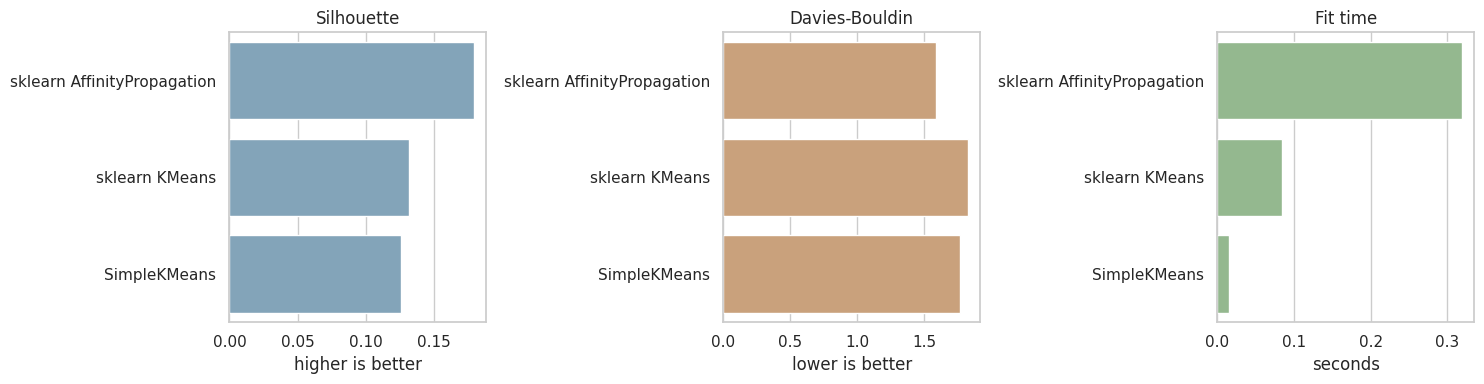

In [151]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.barplot(data=best_model_comparison, x="silhouette", y="model", ax=axes[0], color="#7aa6c2")
axes[0].set_title("Silhouette")
axes[0].set_xlabel("higher is better")
axes[0].set_ylabel("")

sns.barplot(data=best_model_comparison, x="davies_bouldin", y="model", ax=axes[1], color="#d6a06f")
axes[1].set_title("Davies-Bouldin")
axes[1].set_xlabel("lower is better")
axes[1].set_ylabel("")

sns.barplot(data=best_model_comparison, x="fit_time_sec", y="model", ax=axes[2], color="#8fbf88")
axes[2].set_title("Fit time")
axes[2].set_xlabel("seconds")
axes[2].set_ylabel("")

plt.tight_layout()


In [152]:
quality_rank = best_model_comparison.sort_values(
    ["silhouette", "adjusted_rand", "normalized_mutual_info"],
    ascending=[False, False, False],
)[
    [
        "model",
        "clusters_found",
        "silhouette",
        "davies_bouldin",
        "adjusted_rand",
        "normalized_mutual_info",
        "fit_time_sec",
    ]
]
quality_rank


,model,clusters_found,silhouette,davies_bouldin,adjusted_rand,normalized_mutual_info,fit_time_sec
0,sklearn AffinityPropagation,50,0.1795,1.5879,0.1491,0.5010,0.3191
1,sklearn KMeans,12,0.1317,1.8246,0.1493,0.3264,0.0845
2,SimpleKMeans,10,0.1258,1.7689,0.1504,0.2984,0.0149


По итоговой таблице выбираем модель с наилучшим балансом качества и времени. Основной критерий для подбора — `silhouette`, потому что он не использует метки `class`.


## 7. PCA и качество кластеризации

Проверим, как снижение размерности методом главных компонент влияет на качество кластеризации. Для каждой размерности обучаем все три использованные реализации: `SimpleKMeans`, `sklearn KMeans` и `sklearn AffinityPropagation`. Гиперпараметры берем из лучших запусков предыдущего раздела, а для `AffinityPropagation` пересчитываем `preference` как тот же квантиль сходства уже в PCA-пространстве.


In [153]:
from sklearn.decomposition import PCA

pca_component_grid = [2, 5, 10, 20, 40, 60, X_scaled.shape[1]]
pca_model = PCA(n_components=max(pca_component_grid), random_state=42)
X_pca_full = pca_model.fit_transform(X_scaled)

pca_variance = pd.DataFrame(
    {
        "component": np.arange(1, len(pca_model.explained_variance_ratio_) + 1),
        "explained_variance_ratio": pca_model.explained_variance_ratio_,
        "cumulative_explained_variance": np.cumsum(pca_model.explained_variance_ratio_),
    }
)

pca_variance_at_grid = pd.DataFrame(
    {
        "n_components": pca_component_grid,
        "cumulative_explained_variance": [
            pca_variance.loc[n_components - 1, "cumulative_explained_variance"]
            for n_components in pca_component_grid
        ],
    }
)
pca_variance_at_grid


,n_components,cumulative_explained_variance
0,2,0.4226
1,5,0.6533
2,10,0.8057
3,20,0.9020
4,40,0.9716
5,60,0.9939
6,77,1.0000


In [154]:
best_params_by_model = best_runs.set_index("model").to_dict("index")
pca_rows = []
pca_artifacts = {}

for n_components in pca_component_grid:
    X_pca = X_pca_full[:, :n_components]
    pca_similarity = -pairwise_distances(X_pca, metric="sqeuclidean")
    pca_off_diagonal = pca_similarity[np.triu_indices_from(pca_similarity, k=1)]

    for model_name in ["SimpleKMeans", "sklearn KMeans", "sklearn AffinityPropagation"]:
        params = best_params_by_model[model_name]

        if model_name == "SimpleKMeans":
            model = SimpleKMeans(
                n_clusters=int(params["n_clusters"]),
                max_iter=100,
                tol=1e-4,
                random_state=42,
            )
            pca_params = {"n_clusters": int(params["n_clusters"])}
        elif model_name == "sklearn KMeans":
            model = KMeans(
                n_clusters=int(params["n_clusters"]),
                n_init=int(params["n_init"]),
                random_state=42,
            )
            pca_params = {
                "n_clusters": int(params["n_clusters"]),
                "n_init": int(params["n_init"]),
            }
        else:
            preference_quantile = float(params["preference_quantile"])
            preference = float(np.quantile(pca_off_diagonal, preference_quantile))
            model = AffinityPropagation(
                damping=float(params["damping"]),
                preference=preference,
                max_iter=120,
                convergence_iter=10,
                random_state=42,
            )
            pca_params = {
                "damping": float(params["damping"]),
                "preference_quantile": preference_quantile,
                "preference": preference,
            }

        start_time = perf_counter()
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=ConvergenceWarning)
            labels = model.fit_predict(X_pca)
        fit_time_sec = perf_counter() - start_time

        run_id = f"pca_{n_components}_{model_name.replace(' ', '_')}"
        pca_rows.append(
            {
                "run_id": run_id,
                "model": model_name,
                "n_components": n_components,
                "cumulative_explained_variance": pca_variance.loc[
                    n_components - 1, "cumulative_explained_variance"
                ],
                "fit_time_sec": fit_time_sec,
                **pca_params,
                **evaluate_clustering(X_pca, labels, true_class_labels),
            }
        )
        pca_artifacts[run_id] = {"model": model, "labels": labels}

pca_clustering_results = pd.DataFrame(pca_rows)
pca_clustering_results.sort_values(
    ["model", "silhouette", "calinski_harabasz"],
    ascending=[True, False, False],
).groupby("model", as_index=False).head(3)


,run_id,model,n_components,cumulative_explained_variance,fit_time_sec,n_clusters,clusters_found,silhouette,calinski_harabasz,davies_bouldin,adjusted_rand,normalized_mutual_info,n_init,damping,preference_quantile,preference
0,pca_2_SimpleKMeans,SimpleKMeans,2,0.4226,0.0226,10.0000,10,0.3400,728.3276,0.8533,0.0942,0.2185,NaN,NaN,NaN,NaN
3,pca_5_SimpleKMeans,SimpleKMeans,5,0.6533,0.0081,10.0000,10,0.2070,216.0821,1.3053,0.1476,0.3000,NaN,NaN,NaN,NaN
6,pca_10_SimpleKMeans,SimpleKMeans,10,0.8057,0.0129,10.0000,10,0.1800,154.6513,1.4635,0.1477,0.2895,NaN,NaN,NaN,NaN
2,pca_2_sklearn_AffinityPropagation,sklearn AffinityPropagation,2,0.4226,0.2552,NaN,18,0.3381,726.9542,0.8165,0.0756,0.2315,NaN,0.8500,0.0500,-197.1730
11,pca_20_sklearn_AffinityPropagation,sklearn AffinityPropagation,20,0.9020,0.2847,NaN,43,0.1987,67.1064,1.4577,0.1542,0.4813,NaN,0.8500,0.0500,-302.7714
5,pca_5_sklearn_AffinityPropagation,sklearn AffinityPropagation,5,0.6533,0.3413,NaN,29,0.1951,150.3688,1.3253,0.0986,0.3349,NaN,0.8500,0.0500,-248.4250
1,pca_2_sklearn_KMeans,sklearn KMeans,2,0.4226,0.1239,12.0000,12,0.3428,752.8885,0.8089,0.0952,0.2312,10.0000,NaN,NaN,NaN
4,pca_5_sklearn_KMeans,sklearn KMeans,5,0.6533,0.0873,12.0000,12,0.2086,209.1685,1.3062,0.1347,0.2940,10.0000,NaN,NaN,NaN
7,pca_10_sklearn_KMeans,sklearn KMeans,10,0.8057,0.0841,12.0000,12,0.1864,147.3600,1.4887,0.1479,0.3261,10.0000,NaN,NaN,NaN


In [155]:
best_pca_by_model = (
    pca_clustering_results
    .sort_values(["model", "silhouette", "calinski_harabasz"], ascending=[True, False, False])
    .groupby("model", as_index=False)
    .head(1)
    .sort_values("silhouette", ascending=False)
)
best_pca_by_model


,run_id,model,n_components,cumulative_explained_variance,fit_time_sec,n_clusters,clusters_found,silhouette,calinski_harabasz,davies_bouldin,adjusted_rand,normalized_mutual_info,n_init,damping,preference_quantile,preference
1,pca_2_sklearn_KMeans,sklearn KMeans,2,0.4226,0.1239,12.0000,12,0.3428,752.8885,0.8089,0.0952,0.2312,10.0000,NaN,NaN,NaN
0,pca_2_SimpleKMeans,SimpleKMeans,2,0.4226,0.0226,10.0000,10,0.3400,728.3276,0.8533,0.0942,0.2185,NaN,NaN,NaN,NaN
2,pca_2_sklearn_AffinityPropagation,sklearn AffinityPropagation,2,0.4226,0.2552,NaN,18,0.3381,726.9542,0.8165,0.0756,0.2315,NaN,0.8500,0.0500,-197.1730


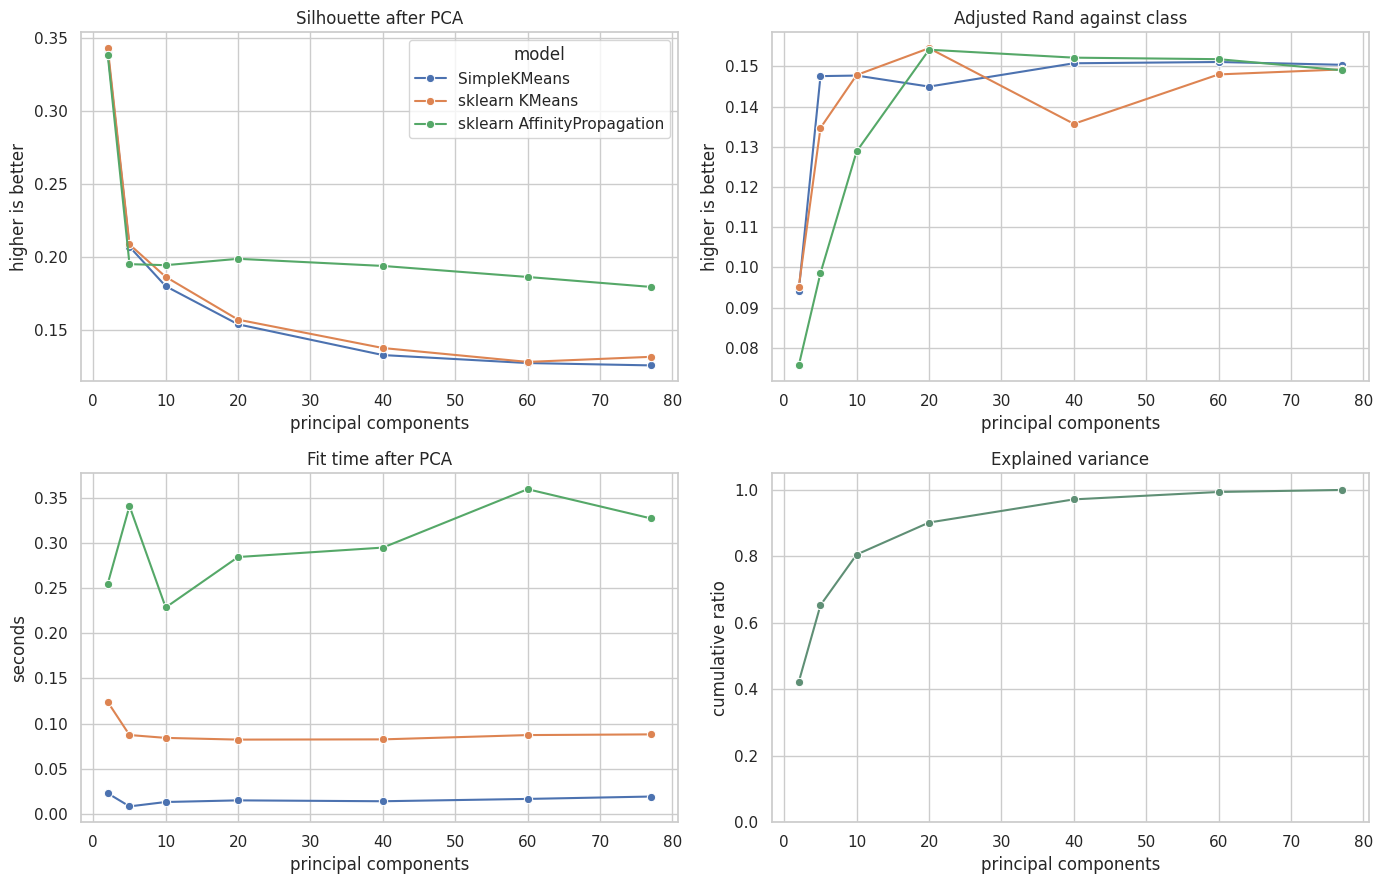

In [156]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.lineplot(
    data=pca_clustering_results,
    x="n_components",
    y="silhouette",
    hue="model",
    marker="o",
    ax=axes[0, 0],
)
axes[0, 0].set_title("Silhouette after PCA")
axes[0, 0].set_xlabel("principal components")
axes[0, 0].set_ylabel("higher is better")

sns.lineplot(
    data=pca_clustering_results,
    x="n_components",
    y="adjusted_rand",
    hue="model",
    marker="o",
    legend=False,
    ax=axes[0, 1],
)
axes[0, 1].set_title("Adjusted Rand against class")
axes[0, 1].set_xlabel("principal components")
axes[0, 1].set_ylabel("higher is better")

sns.lineplot(
    data=pca_clustering_results,
    x="n_components",
    y="fit_time_sec",
    hue="model",
    marker="o",
    legend=False,
    ax=axes[1, 0],
)
axes[1, 0].set_title("Fit time after PCA")
axes[1, 0].set_xlabel("principal components")
axes[1, 0].set_ylabel("seconds")

sns.lineplot(
    data=pca_variance_at_grid,
    x="n_components",
    y="cumulative_explained_variance",
    marker="o",
    ax=axes[1, 1],
    color="#5f8f75",
)
axes[1, 1].set_title("Explained variance")
axes[1, 1].set_xlabel("principal components")
axes[1, 1].set_ylabel("cumulative ratio")
axes[1, 1].set_ylim(0, 1.05)

plt.tight_layout()


In [157]:
pca_summary_table = best_pca_by_model[
    [
        "model",
        "n_components",
        "cumulative_explained_variance",
        "clusters_found",
        "silhouette",
        "davies_bouldin",
        "adjusted_rand",
        "normalized_mutual_info",
        "fit_time_sec",
    ]
]
pca_summary_table


,model,n_components,cumulative_explained_variance,clusters_found,silhouette,davies_bouldin,adjusted_rand,normalized_mutual_info,fit_time_sec
1,sklearn KMeans,2,0.4226,12,0.3428,0.8089,0.0952,0.2312,0.1239
0,SimpleKMeans,2,0.4226,10,0.3400,0.8533,0.0942,0.2185,0.0226
2,sklearn AffinityPropagation,2,0.4226,18,0.3381,0.8165,0.0756,0.2315,0.2552


PCA дает отдельный компромисс между сохраненной дисперсией, скоростью и качеством кластеризации. Слишком малое число компонент ускоряет обучение, но может выбрасывать часть структуры данных. Таблица `pca_summary_table` фиксирует лучшую размерность для каждой модели по `silhouette`; внешние метрики снова используются только как дополнительная проверка совпадения с `class`.


## 8. Визуализация через PCA и t-SNE

Снизим размерность до 2 и 3 координат для визуальной проверки структуры данных. PCA показывает линейную проекцию с максимальной сохраненной дисперсией. t-SNE строим после предварительного PCA до 30 компонент, чтобы ускорить расчет и убрать часть шума. Цветом отдельно покажем известные классы `class` и кластеры лучшей KMeans-модели.


In [158]:
visual_cluster_source = "sklearn KMeans"

visualization_df = pd.DataFrame(
    {
        "PCA 1": X_pca_full[:, 0],
        "PCA 2": X_pca_full[:, 1],
        "PCA 3": X_pca_full[:, 2],
        "class": df["class"].to_numpy(),
        "cluster": best_labels[visual_cluster_source].astype(str).to_numpy(),
    },
    index=df.index,
)

visualization_df.head()


,PCA 1,PCA 2,PCA 3,class,cluster
0,4.7163,-5.3135,-2.0370,c-CS-m,11
1,3.1014,-5.4145,-1.0912,c-CS-m,11
2,3.2196,-5.6224,-0.8620,c-CS-m,11
3,0.7024,-3.9327,-2.7475,c-CS-m,11
4,-0.3458,-4.2727,-1.5667,c-CS-m,11


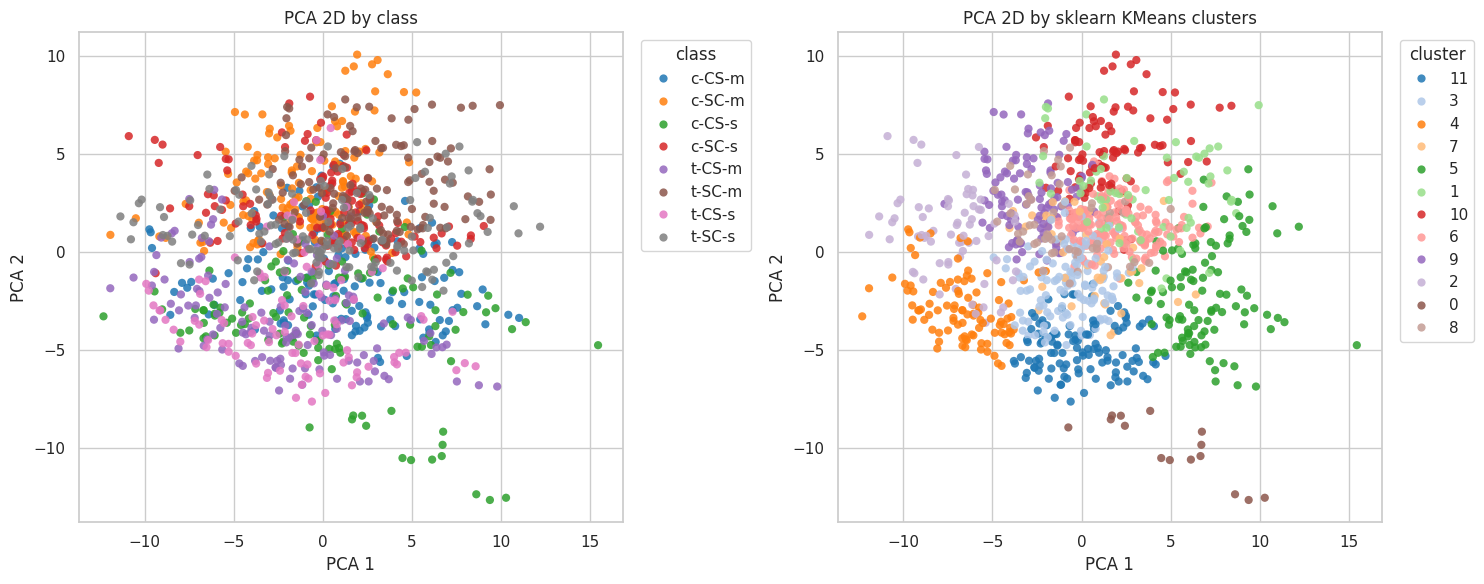

In [159]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(
    data=visualization_df,
    x="PCA 1",
    y="PCA 2",
    hue="class",
    s=35,
    linewidth=0,
    alpha=0.85,
    palette="tab10",
    ax=axes[0],
)
axes[0].set_title("PCA 2D by class")
axes[0].legend(title="class", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.scatterplot(
    data=visualization_df,
    x="PCA 1",
    y="PCA 2",
    hue="cluster",
    s=35,
    linewidth=0,
    alpha=0.85,
    palette="tab20",
    ax=axes[1],
)
axes[1].set_title(f"PCA 2D by {visual_cluster_source} clusters")
axes[1].legend(title="cluster", bbox_to_anchor=(1.02, 1), loc="upper left", ncol=1)

plt.tight_layout()


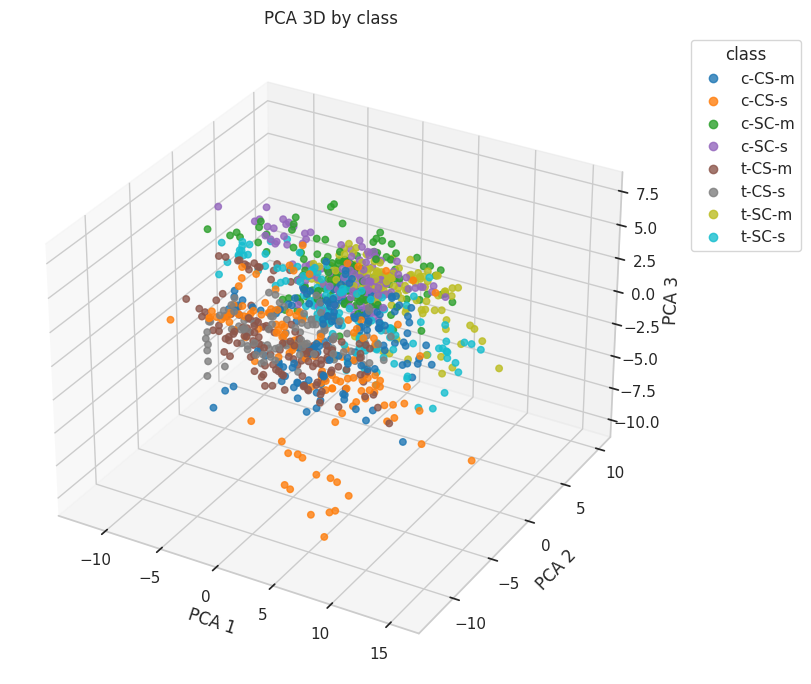

In [160]:
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

class_codes = pd.Categorical(visualization_df["class"]).codes
scatter = ax.scatter(
    visualization_df["PCA 1"],
    visualization_df["PCA 2"],
    visualization_df["PCA 3"],
    c=class_codes,
    cmap="tab10",
    s=22,
    alpha=0.8,
)
ax.set_title("PCA 3D by class")
ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")

class_categories = pd.Categorical(visualization_df["class"]).categories
handles, _ = scatter.legend_elements()
ax.legend(handles, class_categories, title="class", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()


In [161]:
from sklearn.manifold import TSNE

tsne_input_components = min(30, X_pca_full.shape[1])
X_tsne_input = X_pca_full[:, :tsne_input_components]

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    max_iter=1000,
    random_state=42,
)
X_tsne = tsne.fit_transform(X_tsne_input)

visualization_df["t-SNE 1"] = X_tsne[:, 0]
visualization_df["t-SNE 2"] = X_tsne[:, 1]
visualization_df[["t-SNE 1", "t-SNE 2", "class", "cluster"]].head()


,t-SNE 1,t-SNE 2,class,cluster
0,-3.3819,-34.8178,c-CS-m,11
1,-3.6471,-34.6303,c-CS-m,11
2,-3.6856,-34.6425,c-CS-m,11
3,-6.0221,-31.0944,c-CS-m,11
4,-6.5211,-30.9639,c-CS-m,11


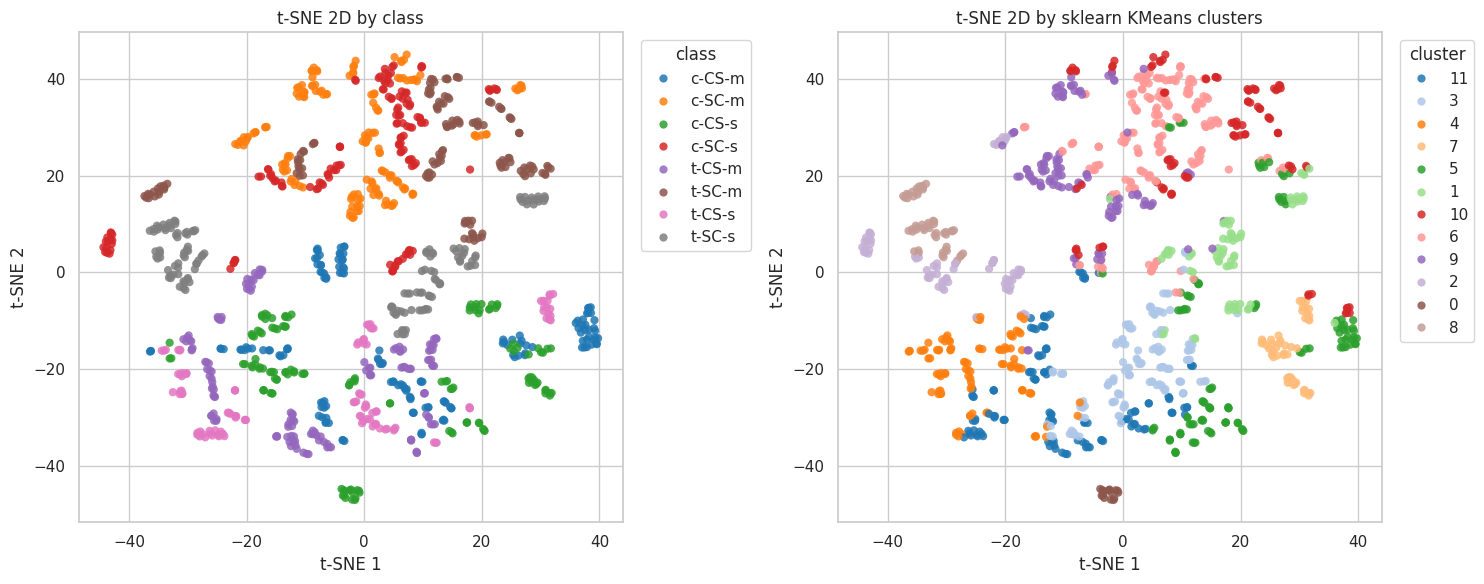

In [162]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(
    data=visualization_df,
    x="t-SNE 1",
    y="t-SNE 2",
    hue="class",
    s=35,
    linewidth=0,
    alpha=0.85,
    palette="tab10",
    ax=axes[0],
)
axes[0].set_title("t-SNE 2D by class")
axes[0].legend(title="class", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.scatterplot(
    data=visualization_df,
    x="t-SNE 1",
    y="t-SNE 2",
    hue="cluster",
    s=35,
    linewidth=0,
    alpha=0.85,
    palette="tab20",
    ax=axes[1],
)
axes[1].set_title(f"t-SNE 2D by {visual_cluster_source} clusters")
axes[1].legend(title="cluster", bbox_to_anchor=(1.02, 1), loc="upper left", ncol=1)

plt.tight_layout()


PCA-графики показывают глобальную линейную структуру данных, а t-SNE лучше подчеркивает локальные группы объектов. Раскраска по `class` помогает визуально проверить, насколько экспериментальные группы отделяются без использования этих меток при обучении. Раскраска по кластерам показывает, как лучшая KMeans-модель делит то же пространство.
